In [165]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
pd.options.display.max_rows

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from scipy.stats import boxcox

In [146]:
cars = sns.load_dataset('mpg')
cars.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [147]:
cars.dropna(inplace=True)

In [148]:
X = cars.drop(columns = ['origin', 'name', 'mpg'])
y = cars['mpg']
 
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 42
                                                   )


model = LinearRegression()
model = model.fit(X_train, y_train)

y_predicted = model.predict(X_test)
y_estimated = model.predict(X_train)

print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, y_estimated))
print('RMSE_train =', root_mean_squared_error(y_train, y_estimated))

print(model.coef_)
 

Train r2 = 0.8107227953093896
Test r2 = 0.7942349075428587
MAE_test = 2.5038600897761274
RMSE_test = 3.2407360783342596
MAE_train = 2.669175930481722
RMSE_train = 3.4559142294242147
[-0.116173    0.00101347 -0.00227634 -0.00656101  0.06173551  0.76063644]


In [149]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2'):
    scores = cross_val_score(model, X, y, cv=kf, scoring = 'r2')
 
    print(f"Scores: {scores}")
    print(f"Mean: {scores.mean()}")
    print(f"Std: {scores.std()}")
    return scores

In [150]:
baseline = cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2')
baseline

Scores: [0.8468912  0.71756673 0.84655687 0.76832679 0.78784604 0.75049785
 0.76867992 0.86144984 0.80380594 0.84331323]
Mean: 0.799493441241163
Std: 0.046268703327659526


array([0.8468912 , 0.71756673, 0.84655687, 0.76832679, 0.78784604,
       0.75049785, 0.76867992, 0.86144984, 0.80380594, 0.84331323])

###### Task 1: Convert the categorical columns to dummy columns and train a new model on your enriched dataset. Compare the performance of this model with the previous one.

In [151]:
## One hot encoding exluding name
cars_dummies = pd.get_dummies(cars['origin'], dtype=int, drop_first = True)
cars_dummies.head()

,japan,usa
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


In [152]:
## concat to the original dataframe
cars = pd.concat([cars, cars_dummies], axis=1)
cars.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,japan,usa
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,0,1


In [153]:
## Linear Regression with dummies
X = cars.drop(columns = ['origin', 'name', 'mpg'])
y = cars['mpg']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 42
                                                   )
model = LinearRegression()
model = model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
print('Train r2 =', model.score(X_train, y_train))
print('Test r2 =', model.score(X_test, y_test))

print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))

print('MAE_train =', mean_absolute_error(y_train, model.predict(X_train)))
print('RMSE_train =', root_mean_squared_error(y_train, model.predict(X_train)))

print(model.coef_)

Train r2 = 0.8286865575852228
Test r2 = 0.7922774714022586
MAE_test = 2.4619996980661445
RMSE_test = 3.256114096847398
MAE_train = 2.5445826417298
RMSE_train = 3.287831254830925
[-0.34210131  0.01920596 -0.0216204  -0.00642267  0.04219811  0.79716146
  0.33046978 -2.87549946]


In [154]:
linear_dummies = cross_val_results(X, y, model = LinearRegression(), cv=5, scoring = 'r2')
linear_dummies

Scores: [0.85482316 0.7109095  0.84155348 0.81119531 0.81140758 0.77476047
 0.77654336 0.85064624 0.7987952  0.85873188]
Mean: 0.8089366184505339
Std: 0.043965213324267935


array([0.85482316, 0.7109095 , 0.84155348, 0.81119531, 0.81140758,
       0.77476047, 0.77654336, 0.85064624, 0.7987952 , 0.85873188])

In [155]:
## Ridge regression with dummies
ridge_model = Ridge(alpha=3) 
ridge_model.fit(X_train, y_train)
y_predicted = ridge_model.predict(X_test)
print('Train r2 =', ridge_model.score(X_train, y_train))
print('Test r2 =', ridge_model.score(X_test, y_test))
print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))
print('MAE_train =', mean_absolute_error(y_train, ridge_model.predict(X_train)))
print('RMSE_train =', root_mean_squared_error(y_train, ridge_model.predict(X_train)))
print(ridge_model.coef_)


Train r2 = 0.8285841864731063
Test r2 = 0.7934907819525153
MAE_test = 2.4483907158348237
RMSE_test = 3.246590663072904
MAE_train = 2.5422314466010176
RMSE_train = 3.288813456432382
[-0.31966357  0.01768927 -0.02065184 -0.00640029  0.04254427  0.79154506
  0.4483805  -2.60048581]


In [156]:
ridge_dummies = cross_val_results(X, y, model = Ridge(alpha=3), cv=5, scoring = 'r2')
ridge_dummies

Scores: [0.85551096 0.71167401 0.84369337 0.80905801 0.80988812 0.7753809
 0.77582449 0.85266687 0.80134538 0.85907661]
Mean: 0.8094118710495326
Std: 0.0442066260365981


array([0.85551096, 0.71167401, 0.84369337, 0.80905801, 0.80988812,
       0.7753809 , 0.77582449, 0.85266687, 0.80134538, 0.85907661])

###### Task 2: Scale the features of this dataset and train a new model on them.

In [157]:
## normalise using minmaxscalar features for Lasso regression
from sklearn.preprocessing import MinMaxScaler
norm = MinMaxScaler().fit(X)
X_norm = norm.transform(X)
X_norm



array([[1.        , 0.61757106, 0.45652174, ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.72868217, 0.64673913, ..., 0.        , 0.        ,
        1.        ],
       [1.        , 0.64599483, 0.56521739, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.2       , 0.17312661, 0.20652174, ..., 1.        , 0.        ,
        1.        ],
       [0.2       , 0.13436693, 0.17934783, ..., 1.        , 0.        ,
        1.        ],
       [0.2       , 0.13178295, 0.19565217, ..., 1.        , 0.        ,
        1.        ]], shape=(392, 8))

In [158]:
## use the scaled data
X_train, X_test, y_train, y_test = train_test_split(X_norm,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 42
                                                   )

lasso_model = Lasso(alpha=0.15) # use Lasso model - penalises magnitude of coefficients. alpha = 30 is "Large", so penalises relatively agressively
lasso_model.fit(X_train, y_train)
y_predicted = lasso_model.predict(X_test)
print('Train r2 =', lasso_model.score(X_train, y_train))
print('Test r2 =', lasso_model.score(X_test, y_test))
print('MAE_test =', mean_absolute_error(y_test, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test, y_predicted))
print('MAE_train =', mean_absolute_error(y_train, lasso_model.predict(X_train)))
print('RMSE_train =', root_mean_squared_error(y_train, lasso_model.predict(X_train)))
print(lasso_model.coef_)

Train r2 = 0.8153237571068566
Test r2 = 0.7978113091799984
MAE_test = 2.3232573277488098
RMSE_test = 3.2124490196667246
MAE_train = 2.5326280443278923
RMSE_train = 3.4136525379071334
[ -1.67977854  -0.          -0.         -16.7075407    0.
   8.36879957   0.04955946  -2.42962735]


In [159]:
lasso_stand = cross_val_results(X, y, model = Lasso(alpha=.15), cv=5, scoring = 'r2')
lasso_stand

Scores: [0.85141854 0.71490772 0.84906364 0.79474616 0.80046905 0.764668
 0.78392632 0.86329912 0.80689133 0.86177418]
Mean: 0.8091164058370488
Std: 0.04567884403003289


array([0.85141854, 0.71490772, 0.84906364, 0.79474616, 0.80046905,
       0.764668  , 0.78392632, 0.86329912, 0.80689133, 0.86177418])

In [160]:
## compare results across each model:
baseline, linear_dummies, ridge_dummies, lasso_stand


(array([0.8468912 , 0.71756673, 0.84655687, 0.76832679, 0.78784604,
        0.75049785, 0.76867992, 0.86144984, 0.80380594, 0.84331323]),
 array([0.85482316, 0.7109095 , 0.84155348, 0.81119531, 0.81140758,
        0.77476047, 0.77654336, 0.85064624, 0.7987952 , 0.85873188]),
 array([0.85551096, 0.71167401, 0.84369337, 0.80905801, 0.80988812,
        0.7753809 , 0.77582449, 0.85266687, 0.80134538, 0.85907661]),
 array([0.85141854, 0.71490772, 0.84906364, 0.79474616, 0.80046905,
        0.764668  , 0.78392632, 0.86329912, 0.80689133, 0.86177418]))

In [161]:
baseline.mean(), linear_dummies.mean(), ridge_dummies.mean(), lasso_stand.mean()

(np.float64(0.799493441241163),
 np.float64(0.8089366184505339),
 np.float64(0.8094118710495326),
 np.float64(0.8091164058370488))

In [162]:
baseline.std(), linear_dummies.std(), ridge_dummies.std(), lasso_stand.std()

(np.float64(0.046268703327659526),
 np.float64(0.043965213324267935),
 np.float64(0.0442066260365981),
 np.float64(0.04567884403003289))

In [163]:
import pandas as pd
summary = pd.DataFrame({
    'Model': ['Baseline', 'Linear (dummies)', 'Ridge (dummies)', 'Lasso (scaled)'],
    'Mean R2': [baseline.mean(), linear_dummies.mean(), ridge_dummies.mean(), lasso_stand.mean()],
    'Std R2': [baseline.std(), linear_dummies.std(), ridge_dummies.std(), lasso_stand.std()]
})
print(summary.to_string(index=False))

           Model  Mean R2   Std R2
        Baseline 0.799493 0.046269
Linear (dummies) 0.808937 0.043965
 Ridge (dummies) 0.809412 0.044207
  Lasso (scaled) 0.809116 0.045679


###### Task 3: Transform the target using the boxcox function.

In [167]:
## transform using boxcox

price_transf, lambda_value = boxcox(cars['mpg'])
price_transf

array([3.85914831, 3.54773592, 3.85914831, 3.65673095, 3.76034861,
       3.54773592, 3.43269633, 3.43269633, 3.43269633, 3.54773592,
       3.54773592, 3.43269633, 3.54773592, 3.43269633, 4.37314516,
       4.21468984, 3.85914831, 4.13104827, 4.59188196, 4.52125666,
       4.44839913, 4.37314516, 4.44839913, 4.52125666, 4.13104827,
       2.89290352, 2.89290352, 3.04229779, 2.73089385, 4.59188196,
       4.66042244, 4.44839913, 3.95360397, 3.65673095, 3.76034861,
       3.95360397, 3.85914831, 3.43269633, 3.43269633, 3.43269633,
       3.43269633, 3.18108218, 3.31080684, 3.31080684, 3.85914831,
       4.21468984, 3.95360397, 3.85914831, 4.29531095, 4.66042244,
       4.79176745, 4.79176745, 4.85480111, 5.09156871, 4.59188196,
       4.52125666, 4.37314516, 4.44839913, 4.29531095, 4.04412082,
       4.13104827, 3.31080684, 3.43269633, 3.54773592, 3.43269633,
       3.76034861, 3.04229779, 3.31080684, 3.18108218, 3.31080684,
       3.95360397, 3.54773592, 3.31080684, 3.31080684, 3.43269

In [ ]:
lambda_value

#0.19 reflects a possible power transformation, but it is not a strong transformation.

np.float64(0.19123084478293514)

<Axes: ylabel='Count'>

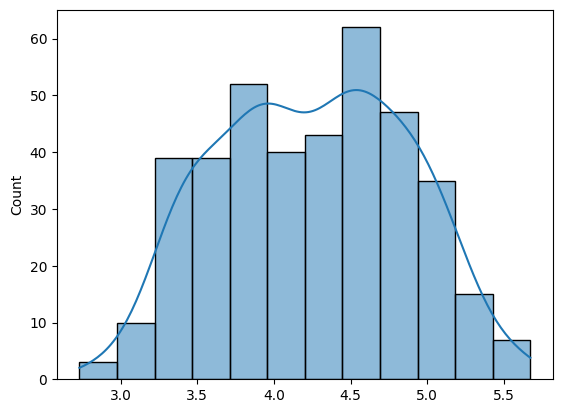

In [ ]:
## hist plot
sns.histplot(price_transf, kde = True)

# This does represent close to a bell curve

###### Task 4: Use another regression model that was discussed today.

In [172]:
## ridge regression against transformed
X_train, X_test, y_train_transf, y_test_transf = train_test_split(X_norm, price_transf, test_size=0.2, random_state = 42)
ridge_regr_model = Ridge(alpha=1)
ridge_regr_model.fit(X_train, y_train_transf)
y_predicted = ridge_regr_model.predict(X_test)

print('Train r2 =', ridge_regr_model.score(X_train, y_train_transf))
print('Test r2 =', ridge_regr_model.score(X_test, y_test_transf))
print('MAE_test =', mean_absolute_error(y_test_transf, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_transf, y_predicted))
print('MAE_train =', mean_absolute_error(y_train_transf, ridge_regr_model.predict(X_train)))
print('RMSE_train =', root_mean_squared_error(y_train_transf, ridge_regr_model.predict(X_train)))

print(ridge_regr_model.coef_)


Train r2 = 0.8716967977869416
Test r2 = 0.8463531591131898
MAE_test = 0.1649841566317312
RMSE_test = 0.22480175530952765
MAE_train = 0.17063453979344248
RMSE_train = 0.22281403677354514
[-0.19767279 -0.02893735 -0.46160127 -1.12821612 -0.10377084  0.65673077
  0.03539588 -0.1516151 ]


In [173]:
cross_val_results(X_norm, price_transf, model = Ridge(alpha=1), cv=5, scoring = 'r2')

Scores: [0.89947661 0.7811494  0.87205994 0.84859693 0.85550615 0.84104642
 0.83613575 0.90645567 0.86023561 0.88181686]
Mean: 0.8582479352759546
Std: 0.034064189423117175


array([0.89947661, 0.7811494 , 0.87205994, 0.84859693, 0.85550615,
       0.84104642, 0.83613575, 0.90645567, 0.86023561, 0.88181686])

In [ ]:
from scipy.special import inv_boxcox
predictions_original_scale = inv_boxcox(y_predicted, lambda_value)
predictions_original_scale


array([25.883754  , 26.32377343, 33.98994092, 23.87859487, 28.368849  ,
       29.70491893, 11.34608087, 29.83595519, 19.95372878, 28.79686165,
       12.87877038, 23.8836725 , 16.18409809, 28.82461488, 22.06049265,
       28.8440633 , 19.9090055 , 33.07993633, 26.82369868, 30.43742948,
       18.52605818, 34.81050447, 35.53119021, 14.94263818, 28.83849407,
       25.78701377, 21.86988882, 16.830379  , 28.33855514, 24.22734353,
       14.2523496 , 22.13908572, 19.49138148, 31.4395988 , 13.24438916,
       36.4893147 , 13.2992373 , 23.82753651, 13.30396926, 10.41538699,
       14.13323763, 27.83290319, 35.69585288, 26.91295444, 13.62973775,
       11.36940368, 17.46753587, 32.3215583 , 23.41734979, 30.66446411,
       13.05622392, 25.27649362, 22.33522675, 34.74262632, 26.05495076,
       17.54864557, 18.9582824 , 21.09234094, 22.82257077, 24.87743281,
       10.70498619, 21.27229734, 24.51483939, 24.19658739, 28.95544001,
       28.54719969, 25.49707129, 29.8216069 , 20.13049017, 11.45

In [179]:
## Lasso regression against transformed
X_train, X_test, y_train_transf, y_test_transf = train_test_split(X_norm, price_transf, test_size=0.2, random_state = 42)
lasso_regr_model = Lasso(alpha=0.01)
lasso_regr_model.fit(X_train, y_train_transf)
y_predicted = lasso_regr_model.predict(X_test)
print('Train r2 =', lasso_regr_model.score(X_train, y_train_transf))
print('Test r2 =', lasso_regr_model.score(X_test, y_test_transf))
print('MAE_test =', mean_absolute_error(y_test_transf, y_predicted))
print('RMSE_test =', root_mean_squared_error(y_test_transf, y_predicted))
print('MAE_train =', mean_absolute_error(y_train_transf, lasso_regr_model.predict(X_train)))
print('RMSE_train =', root_mean_squared_error(y_train_transf, lasso_regr_model.predict(X_train)))
print(lasso_regr_model.coef_)

Train r2 = 0.8659258458882015
Test r2 = 0.8580210702953684
MAE_test = 0.15688193217349108
RMSE_test = 0.21609754316227955
MAE_train = 0.17434824248156486
RMSE_train = 0.22776990039917844
[-0.23932331 -0.         -0.02088744 -1.33619599  0.          0.6356051
  0.         -0.14605241]
